# Genre KNN Validation
Loads `genre_embeddings.json` and validates with KNN.
>
> **Before running**: Make sure `genre_embeddings.json` exists in `data/embeddings/`.

In [45]:
import json
import os
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import umap
import matplotlib
import re
from sklearn.cluster import KMeans
from collections import Counter

## Config

In [46]:
EMBEDDINGS_PATH = "../data/embeddings/genre_embeddings.json"
PLOT_PATH = "../outputs/plots/genre/"

K = 10

QUERY_GENRES = [
    "pop rap", "death metal", "jazz",
    "tropical house", "classical", "edm",
    "blues", "reggaeton", "folk", "house"
]

SPOT_GENRES = ["pop rap", "death metal", "jazz", "rock", "classical", "edm"]

N_CLUSTERS = 30
MIN_CLUSTER_SIZE = 8

## 1. Load Embeddings

In [47]:
os.makedirs(PLOT_PATH, exist_ok=True)

with open(EMBEDDINGS_PATH) as f:
    raw = json.load(f)

genres = list(raw.keys())
token2idx = {g: i for i, g in enumerate(genres)}
X = np.array(list(raw.values()), dtype=np.float32)

print(f"{len(genres)} genres | dim={X.shape[1]}")

1305 genres | dim=32


## 2. KNN

In [48]:
nbrs = NearestNeighbors(n_neighbors=K+1, metric='cosine').fit(X)
distances, indices = nbrs.kneighbors(X)

def knn(query, k=5):
    if query not in token2idx:
        return f"'{query}' not in vocab"
    idx = token2idx[query]
    return [(genres[indices[idx][i]], 1 - distances[idx][i]) for i in range(1, k+1)]

for q in SPOT_GENRES:
    print(f"\n→ {q}")
    for name, sim in knn(q):
        print(f"   {name:<35} {sim:.3f}")


→ pop rap
   rap                                 0.923
   trap music                          0.914
   southern hip hop                    0.898
   crunk                               0.882
   dwn trap                            0.882

→ death metal
   deathgrind                          0.902
   goregrind                           0.893
   black thrash                        0.872
   grindcore                           0.869
   brutal death metal                  0.857

→ jazz
   bebop                               0.930
   hard bop                            0.887
   contemporary post-bop               0.885
   cool jazz                           0.882
   soul jazz                           0.863

→ rock
   album rock                          0.894
   hard rock                           0.883
   classic rock                        0.780
   art rock                            0.746
   soft rock                           0.744

→ classical
   romantic                            0.886


## 3. UMAP Plot

/Users/nicholasburczyk/Desktop/CS_CLASS/CS665sp26/Musical-Blob/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


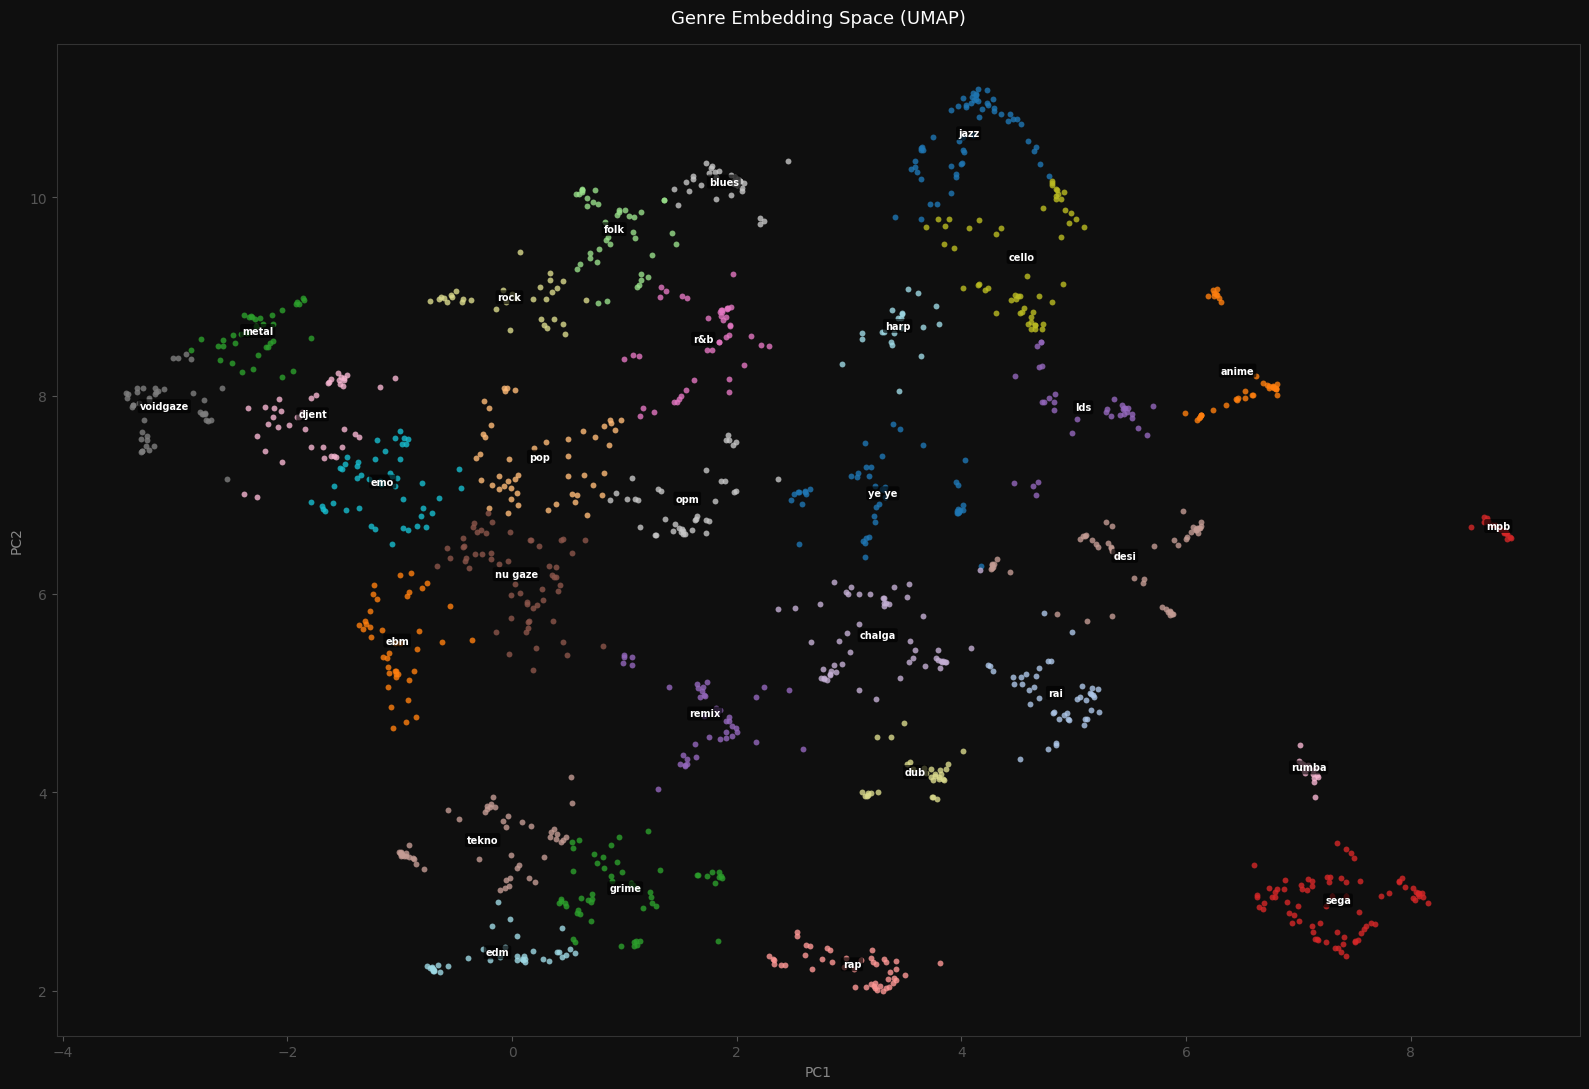

In [49]:
reducer     = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb2d       = reducer.fit_transform(X)

km          = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_ids = km.fit_predict(emb2d)

def is_genre_name(name):
    if len(name) > 35 or len(name) < 3: return False
    if re.search(r'\d', name): return False
    if name[0] in '-_': return False
    if any(c in name for c in [':', '!', '?']): return False
    return True

genre_counts = Counter(genres)

cluster_labels = {}
for ci in range(N_CLUSTERS):
    mask = np.where(cluster_ids == ci)[0]
    if len(mask) < MIN_CLUSTER_SIZE: continue
    names = [genres[i] for i in mask if is_genre_name(genres[i])]
    if names:
        cluster_labels[ci] = max(names, key=lambda g: len(g.split()))

# Use shortest name as proxy for most "canonical" genre (e.g. "rock" over "alternative rock")
cluster_labels = {}
for ci in range(N_CLUSTERS):
    mask = np.where(cluster_ids == ci)[0]
    if len(mask) < MIN_CLUSTER_SIZE: continue
    names = [genres[i] for i in mask if is_genre_name(genres[i])]
    if names:
        cluster_labels[ci] = min(names, key=lambda g: len(g))

cmap_clusters = matplotlib.colormaps['tab20'].resampled(N_CLUSTERS)

fig, ax = plt.subplots(figsize=(16, 11), facecolor='#0f0f0f')
ax.set_facecolor('#0f0f0f')
for ci in range(N_CLUSTERS):
    mask = np.where(cluster_ids == ci)[0]
    if len(mask) == 0: continue
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1], c=[cmap_clusters(ci)], s=18, alpha=0.8, linewidths=0)
    if len(mask) >= MIN_CLUSTER_SIZE and ci in cluster_labels:
        cx, cy = emb2d[mask, 0].mean(), emb2d[mask, 1].mean()
        ax.annotate(cluster_labels[ci], (cx, cy), color='white', fontsize=7,
                    ha='center', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#000000aa', edgecolor='none'))
ax.set_title('Genre Embedding Space (UMAP)', color='white', fontsize=13, pad=15)
ax.set_xlabel('PC1', color='#888888'); ax.set_ylabel('PC2', color='#888888')
ax.tick_params(colors='#555555')
for spine in ax.spines.values(): spine.set_color('#333333')
plt.tight_layout()
plt.savefig(PLOT_PATH + "genre_embedding_space.png")
plt.show()

## 4. Cosine Similarity Heatmap

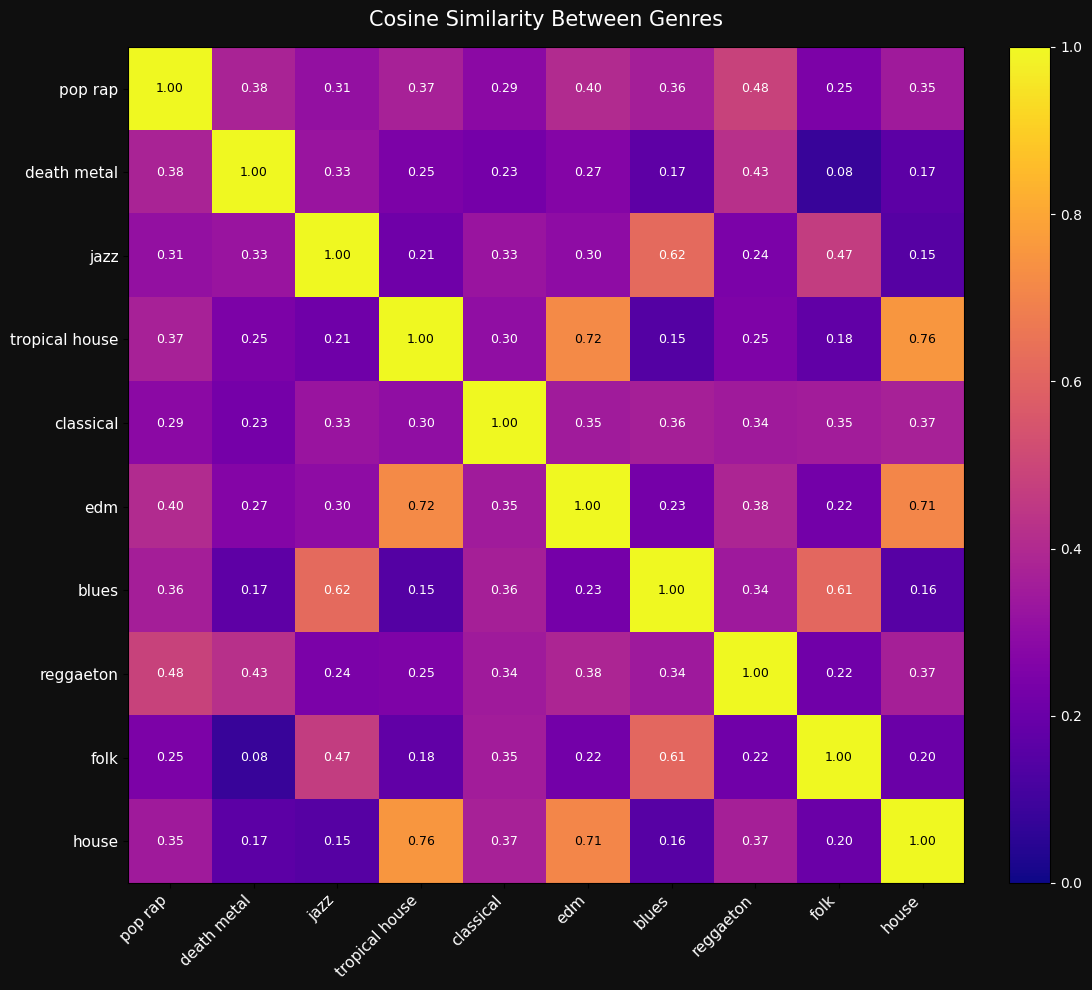

In [50]:
q_genres = [q for q in QUERY_GENRES if q in token2idx]
n = len(q_genres)
sim_matrix = np.zeros((n, n))
for i, ga in enumerate(q_genres):
    va = X[token2idx[ga]]
    for j, gb in enumerate(q_genres):
        vb = X[token2idx[gb]]
        sim_matrix[i,j] = max(0, (np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb)+1e-9)))

fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0f0f0f')
ax.set_facecolor('#0f0f0f')
im = ax.imshow(sim_matrix, cmap='plasma', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(q_genres, rotation=45, ha='right', color='white', fontsize=11)
ax.set_yticks(range(n)); ax.set_yticklabels(q_genres, color='white', fontsize=11)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                color='white' if sim_matrix[i,j] < 0.7 else 'black', fontsize=9)
cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')
ax.set_title('Cosine Similarity Between Genres', color='white', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig(PLOT_PATH + "genre_cosine_similarity.png")
plt.show()

## 5. KNN Neighbour Bar Charts

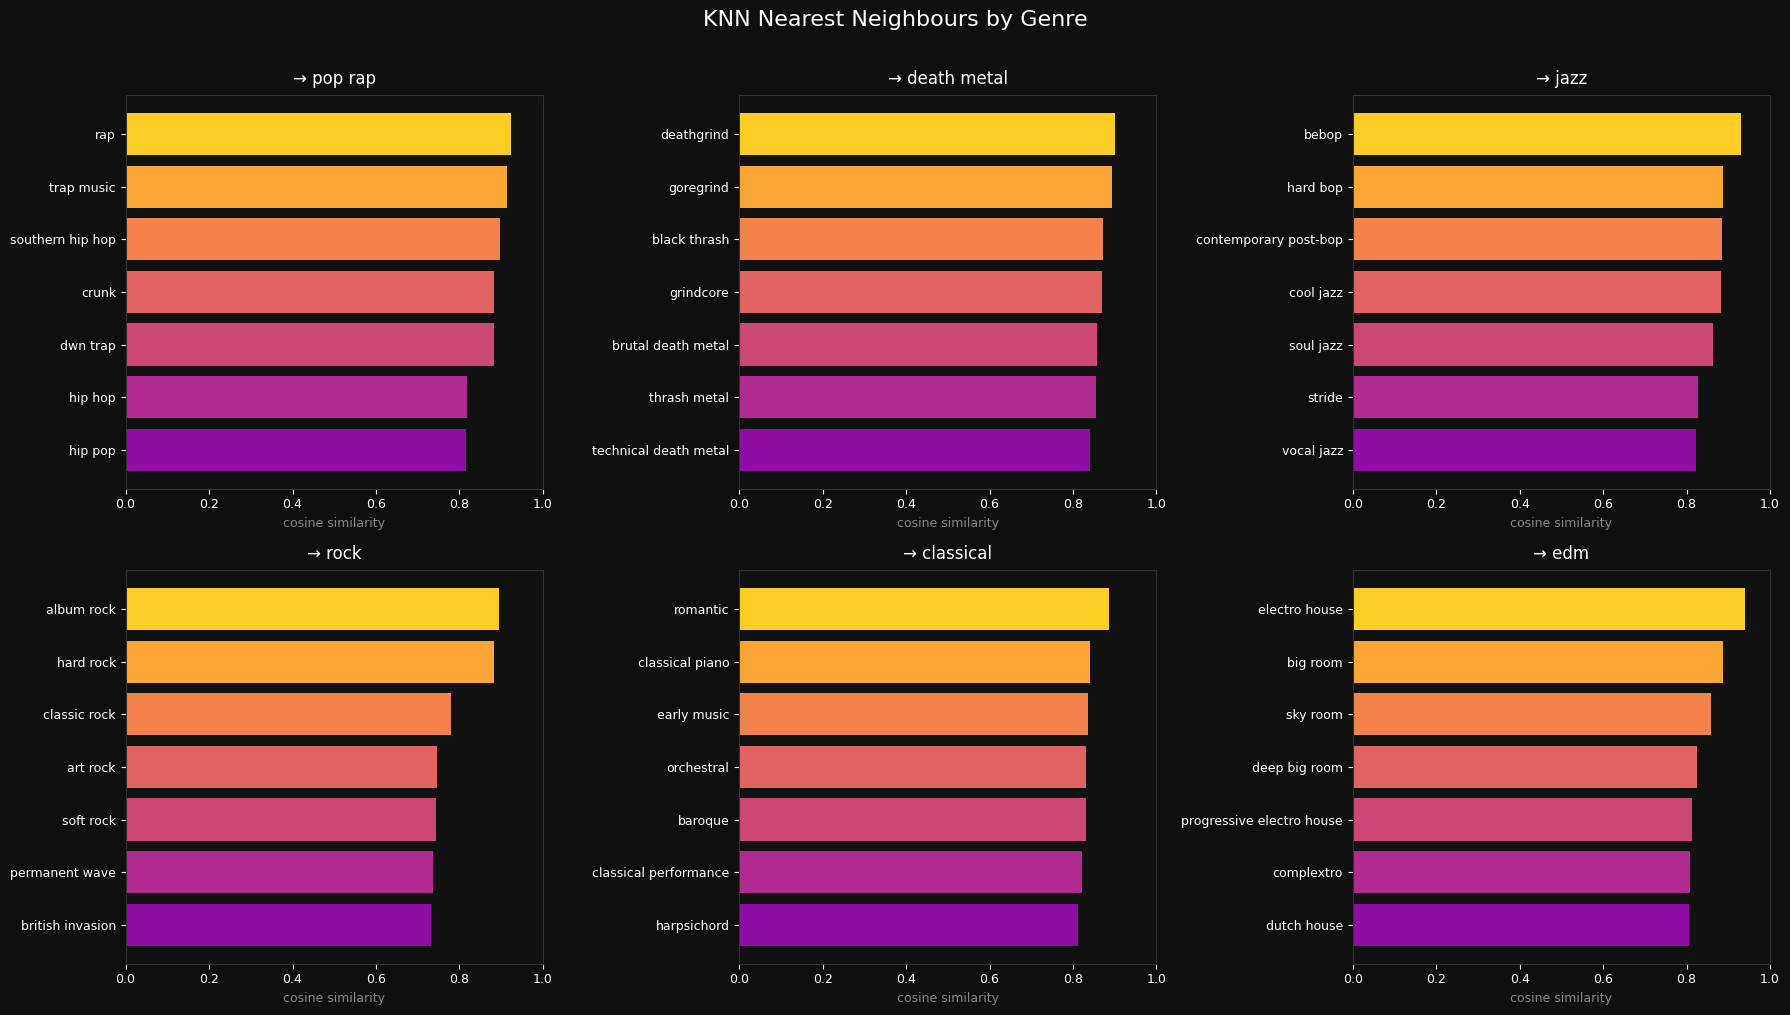

In [51]:
def is_clean(name):
    if len(name) > 40: return False
    if any(c.isdigit() for c in name): return False
    return True

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#0f0f0f')
axes = axes.flatten()

for ax, q in zip(axes, SPOT_GENRES):
    ax.set_facecolor('#111111')
    if q not in token2idx:
        ax.set_visible(False); continue
    idx = token2idx[q]

    neighbours = []
    for i in range(1, len(indices[idx])):
        name = genres[indices[idx][i]]
        if is_clean(name):
            neighbours.append((name, 1 - distances[idx][i]))
        if len(neighbours) == 7: break

    names = [n for n, _ in neighbours]
    sims  = [s for _, s in neighbours]

    ax.barh(names[::-1], sims[::-1], color=plt.cm.plasma(np.linspace(0.3, 0.9, len(names))))
    ax.set_xlim(0, 1)
    ax.set_title(f'→ {q}', color='white', fontsize=12, pad=8)
    ax.tick_params(colors='white', labelsize=9)
    ax.set_xlabel('cosine similarity', color='#888888', fontsize=9)
    for spine in ax.spines.values(): spine.set_color('#333333')

plt.suptitle('KNN Nearest Neighbours by Genre', color='white', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_PATH + "genre_nearest_neighbors.png")
plt.show()

## 6. Metrics

In [53]:
norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / (norms + 1e-9)

sim_matrix = X_norm @ X_norm.T
mask = np.triu(np.ones(len(genres), dtype=bool), k=1)
mean_sim = sim_matrix[mask].mean()

eigvals = np.linalg.eigvalsh(X_norm.T @ X_norm)
eigvals = eigvals[eigvals > 0]
isotropy = np.exp(-(eigvals / eigvals.sum() * np.log(eigvals / eigvals.sum() + 1e-9)).sum()) / len(eigvals)

print(f"Mean pairwise similarity: {mean_sim:.3f}  (lower = more spread)")
print(f"Isotropy:                 {isotropy:.3f}  (higher = better use of space)")

Mean pairwise similarity: 0.305  (lower = more spread)
Isotropy:                 0.598  (higher = better use of space)
